# 05 · Baseline Walk-Forward Backtest

In [1]:
import sys
import warnings
from pathlib import Path
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
import matplotlib.ticker as ticker
 
# ── path setup ────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path(".").resolve().parent   
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")
 
# ── project imports ───────────────────────────────────────────────────────────
from statarb.context  import AppContext
from statarb.pipeline import BaselinePipelineV1_P3
from statarb.metrics  import get_backtest_metrics, save_strategy_outputs
from statarb.backtest import make_daily_rates
 
# ── shared context ────────────────────────────────────────────────────────────
ctx = AppContext.instance(config_path=str(PROJECT_ROOT / "config.yaml"))
cfg = ctx.cfg
 
OUTPUT_DIR = Path(cfg["data"]["output_dir"])
TEST_DIR   = Path(cfg["data"]["test_dir"])
PLOT_DIR   = Path(cfg["data"]["plot_dir"])
TEST_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
 
# ── visual style ──────────────────────────────────────────────────────────────
METHODS = ["corr", "dist", "coint", "combined"]

COLORS  = {"corr": "#2196F3", "dist": "#FF9800", "coint": "#4CAF50", "combined": "#E53935"}
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})


## 1 · Pair Counts per Method per Year


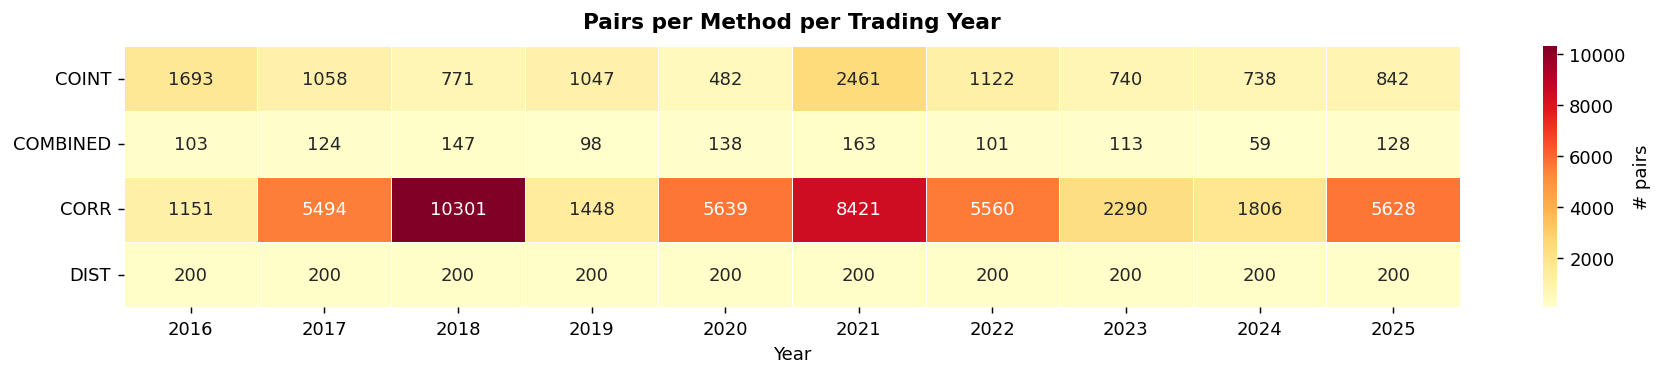

In [2]:
records = []
for method in METHODS:
    for f in sorted(OUTPUT_DIR.glob(f"pairs_{method}_*.parquet")):
        year = int(f.stem.split("_")[-1][:4])
        n    = len(pd.read_parquet(f))
        records.append({"Method": method.upper(), "Year": year, "Pairs": n})
 
df_counts = pd.DataFrame(records)
pivot = df_counts.pivot(index="Method", columns="Year", values="Pairs").fillna(0).astype(int)
 
fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.4, cbar_kws={"label": "# pairs"}, ax=ax)
ax.set_title("Pairs per Method per Trading Year", fontsize=12, fontweight="bold", pad=10)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PLOT_DIR / "05_pair_counts.png", dpi=150, bbox_inches="tight")
plt.show()

## 2 · Run Baseline Backtest 

In [3]:
pipeline = BaselinePipelineV1_P3(cfg, ctx)
results  = {}   
 
for method in METHODS:
    metrics_path       = TEST_DIR / f"backtest_baselineV1-P3_tx_metrics_{method}.parquet"
    returns_path       = TEST_DIR / f"backtest_baselineV1-P3_tx_returns_{method}.parquet"
    pairs_attr_path    = TEST_DIR / f"backtest_baselineV1-P3_tx_pairs_attr_{method}.parquet"
    pairs_metrics_path = TEST_DIR / f"backtest_baselineV1-P3_tx_pairs_metrics_{method}.parquet"
    netted_path        = TEST_DIR / f"backtest_baselineV1-P3_tx_netted_{method}.parquet"  

    # ── load cache if available ───────────────────────────────────────────────
    if (metrics_path.exists() and returns_path.exists() and 
        pairs_attr_path.exists() and pairs_metrics_path.exists() and netted_path.exists()):

        df_m = pd.read_parquet(metrics_path)
        df_r = pd.read_parquet(returns_path)
        df_pa_ret = pd.read_parquet(pairs_attr_path)
        df_pa_met = pd.read_parquet(pairs_metrics_path)
        df_netted = pd.read_parquet(netted_path)
        print(f"[{method.upper():8s}] loaded from cache")

        df_a_dict = {
            "per_pair_returns": df_pa_ret,
            "per_pair_metrics": df_pa_met,
            "df_netted": df_netted
        }
        
        results[method] = (df_m, df_r, df_a_dict)
        continue
 
    # ── run pipeline ──────────────────────────────────────────────────────────
    print(f"\n{'='*60}\n  Running {method.upper()}\n{'='*60}")
    df_m, df_r, df_a_dict = pipeline.run_method(method)
    results[method] = (df_m, df_r, df_a_dict)
 
    if not df_m.empty:
        save_strategy_outputs(
            backtest_records     = df_m,
            pair_returns         = df_r,
            pair_attributes_dict = df_a_dict, 
            metrics_path         = str(metrics_path),
            returns_path         = str(returns_path),
            pairs_attr_path      = str(pairs_attr_path), 
            pairs_metrics_path   = str(pairs_metrics_path),
            netted_path          = str(netted_path),
        )
        print(f"\n  Saved → {metrics_path.name}   ({len(df_m)} years)")
        print(f"  Saved → {returns_path.name}    ({df_r.shape[0]} days × {df_r.shape[1]} cols)")
        print(f"  Saved → {pairs_attr_path.name}  (Individual asset attribution records)")
    else:
        print(f"\n  WARNING: no results for {method}")
 
print("\nAll methods complete.")

[CORR    ] loaded from cache
[DIST    ] loaded from cache
[COINT   ] loaded from cache
[COMBINED] loaded from cache

All methods complete.


## 3 · Growth of $1 — Baseline Performance Comparison

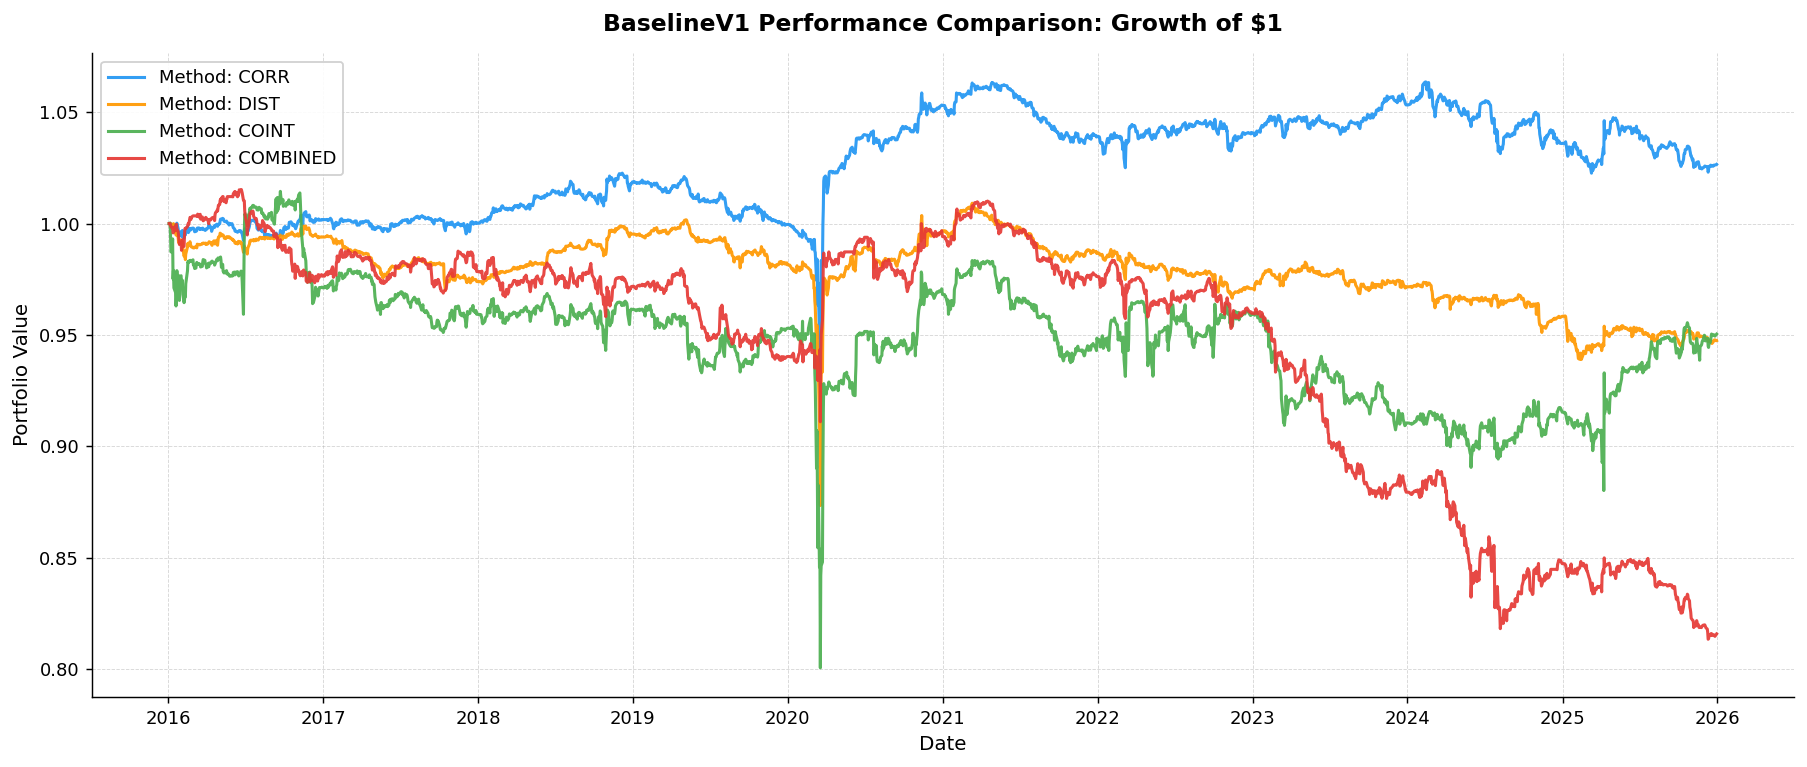

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
 
for method in METHODS:
    df_m, df_r, _ = results[method]
    if df_r.empty:
        continue
    equity = df_r.sum(axis=1).cumsum().apply(np.exp)
    ax.plot(equity.index, equity.values,
            label=f"Method: {method.upper()}",
            color=COLORS[method], linewidth=1.7, alpha=0.92)
 

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=0)
ax.set_title("BaselineV1 Performance Comparison: Growth of $1",
             fontweight="bold",fontsize=13, pad=12)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Portfolio Value",fontsize=11)
ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.5)
ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "05_growth_of_1.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 · Drawdown Comparison

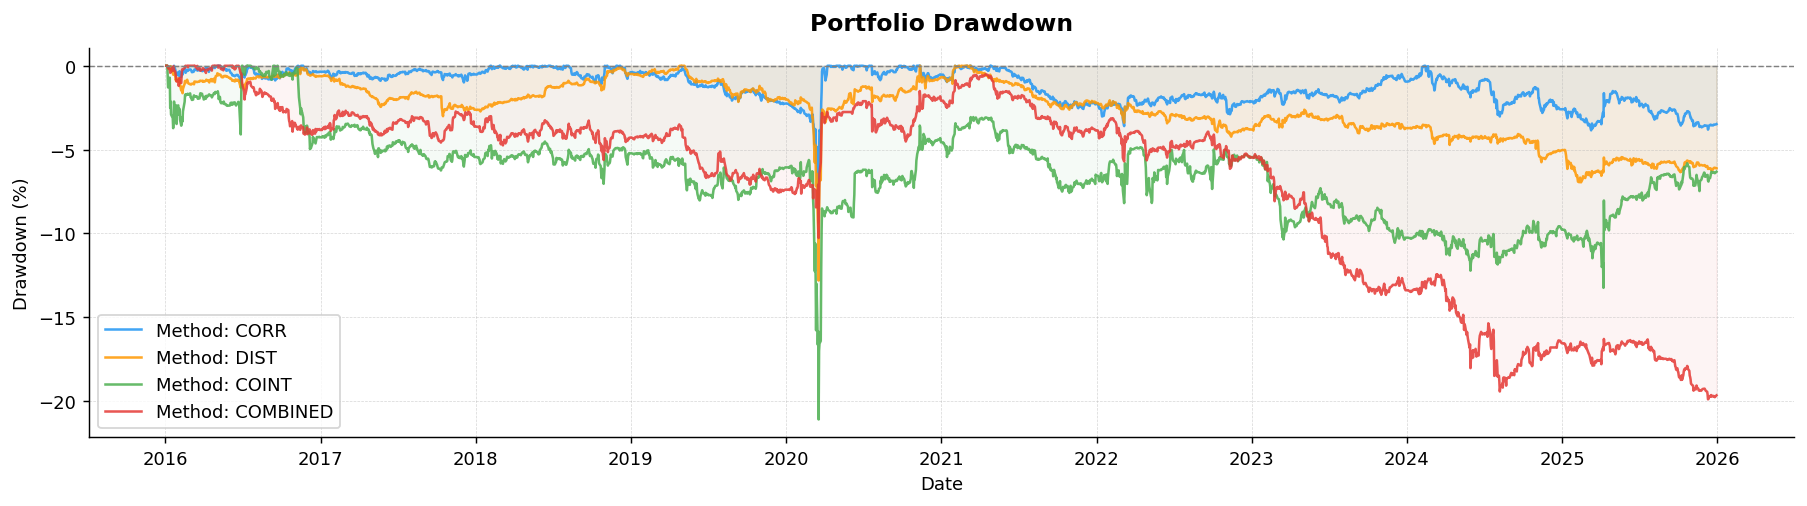

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))

for method in METHODS:
    df_metrics, df_returns, _ = results[method]
    if df_returns.empty:
        continue
    equity_dollar = df_returns.sum(axis=1).cumsum().apply(np.exp)
    drawdown = (equity_dollar / equity_dollar.cummax()) - 1  
    drawdown_pct = drawdown * 100                           
    ax.plot(drawdown_pct.index, drawdown_pct.values,
            label=f"Method: {method.upper()}",
            color=COLORS[method], linewidth=1.4, alpha=0.85)
    ax.fill_between(drawdown_pct.index, drawdown_pct.values, 0,
                    alpha=0.05, color=COLORS[method])

ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Portfolio Drawdown", fontsize=13, fontweight="bold",pad=10)
ax.set_ylabel("Drawdown (%)") 
ax.set_xlabel("Date")
ax.legend(loc="lower left", fontsize=10)
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig(PLOT_DIR / "05_drawdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 · Portfolio-Level Performance Metrics

In [6]:
summary_rows = []
 
for method in METHODS:
    df_m, df_r, df_a = results[method]
    if df_r.empty:
        continue
 
    net_returns = df_r.sum(axis=1)
    equity      = net_returns.cumsum().apply(np.exp).rename("EquityCurve").to_frame()
    
    df_rates    = make_daily_rates(cfg, equity.index)
 
    m = get_backtest_metrics(equity, risk_free_rate=df_rates["rfr"])
 
    if isinstance(df_a, dict) and "df_netted" in df_a:
        df_net = df_a["df_netted"]
        
        position_changes = df_net.diff().fillna(0)
        
        true_net_trades = int((position_changes != 0).sum().sum())
        m["Total Trades"] = true_net_trades
    else:
        m["Total Trades"] = 0
 
    m["Method"] = method.upper()
    summary_rows.append(m)
 
METRIC_COLS = [
    "Sharpe Ratio", "Annual Excess Return", "Annual Volatility",
    "Maximum Drawdown (MDD)", "Calmar Ratio", "Sortino Ratio",
    "Win Rate", "Longest Drawdown Duration", "Total Trades",
]
FMT = {
    "Sharpe Ratio":              "{:.3f}",
    "Annual Excess Return":      "{:.2%}",
    "Annual Volatility":         "{:.2%}",
    "Maximum Drawdown (MDD)":    "{:.2%}",
    "Calmar Ratio":              "{:.3f}",
    "Sortino Ratio":             "{:.3f}",
    "Win Rate":                  "{:.2%}",
    "Longest Drawdown Duration": "{:.0f} days",
    "Total Trades":              "{:.0f}",
}
 
if summary_rows:
    df_summary = pd.DataFrame(summary_rows).set_index("Method")
    valid_cols = [c for c in METRIC_COLS if c in df_summary.columns]
    df_summary = df_summary[valid_cols]
 
    display(
        df_summary.style
        .format({k: v for k, v in FMT.items() if k in df_summary.columns})
        .background_gradient(
            subset=[c for c in ["Sharpe Ratio", "Calmar Ratio", "Sortino Ratio"]
                    if c in df_summary.columns],
            cmap="RdYlGn"
        )
        .set_caption("Baseline_V1 Walk-Forward — Consolidated Portfolio Metrics (Continuous)")
    )

,Sharpe Ratio,Annual Excess Return,Annual Volatility,Maximum Drawdown (MDD),Calmar Ratio,Sortino Ratio,Win Rate,Longest Drawdown Duration,Total Trades
Method,,,,,,,,,
CORR,0.094,0.26%,2.79%,-9.81%,0.027,0.122,48.83%,701 days,73450
DIST,-0.180,-0.54%,3.01%,-13.70%,-0.039,-0.207,48.55%,1207 days,31533
COINT,-0.085,-0.51%,6.00%,-23.69%,-0.022,-0.097,49.22%,2330 days,12178
COMBINED,-0.569,-2.04%,3.59%,-22.18%,-0.092,-0.676,48.79%,2394 days,6619


## 6 · Year-by-Year Sharpe Heatmap

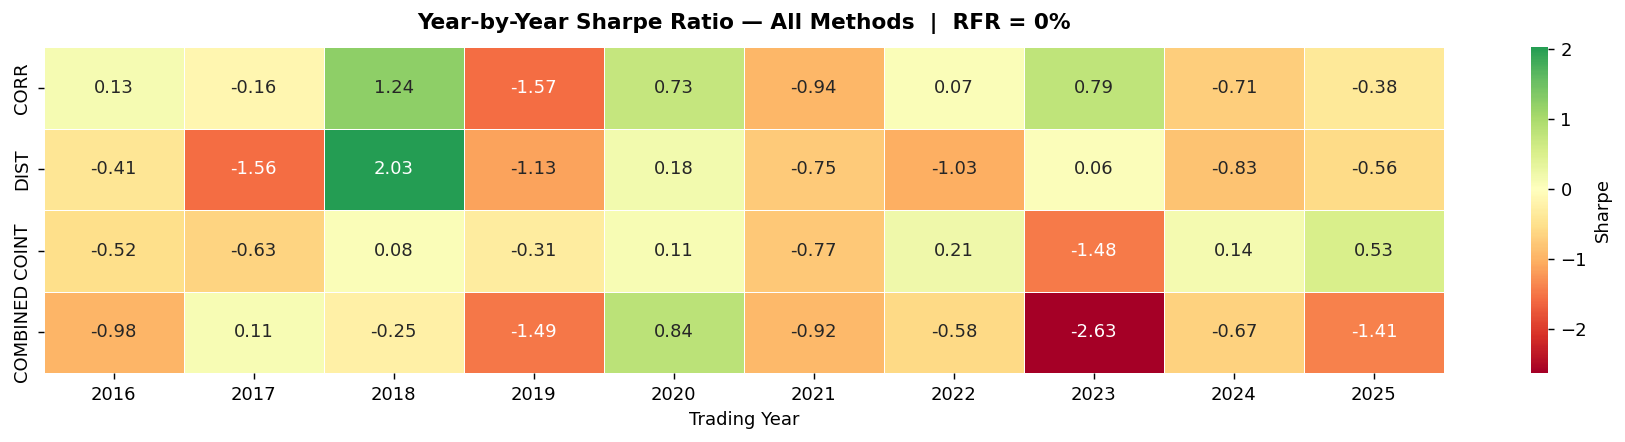

,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
CORR,0.13,-0.16,1.24,-1.57,0.73,-0.94,0.07,0.79,-0.71,-0.38
DIST,-0.41,-1.56,2.03,-1.13,0.18,-0.75,-1.03,0.06,-0.83,-0.56
COINT,-0.52,-0.63,0.08,-0.31,0.11,-0.77,0.21,-1.48,0.14,0.53
COMBINED,-0.98,0.11,-0.25,-1.49,0.84,-0.92,-0.58,-2.63,-0.67,-1.41


In [7]:
yearly_sharpe = {m.upper(): {} for m in METHODS}
 
for method in METHODS:
    df_m, df_r, _ = results[method]
    if df_m.empty:
        continue
    
    for year_str in df_m.index:
        year_int = int(year_str)
        s = df_m.loc[year_str, "Sharpe Ratio"]
        yearly_sharpe[method.upper()][year_int] = round(float(s), 2) if np.isfinite(s) else np.nan
 
df_ys = pd.DataFrame(yearly_sharpe).T.sort_index(axis=1)
 
fig, ax = plt.subplots(figsize=(14, 3.5))
sns.heatmap(
    df_ys.astype(float), annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, linewidths=0.4,
    cbar_kws={"label": "Sharpe"}, ax=ax
)
ax.set_title("Year-by-Year Sharpe Ratio — All Methods  |  RFR = 0%",
             fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Trading Year"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PLOT_DIR / "05 _yearly_sharpe.png", dpi=150, bbox_inches="tight")
plt.show()
display(df_ys)

## 7 · Per-Pair Sharpe Distribution

In [8]:
print("Capital Deployment Check")
print("=" * 55)
print(f"{'Method':<10} {'Yrs':>4}  {'Pairs/Yr (avg)':>14}  {'Weight/Pair':>12}")
print("-" * 55)
 
for method in METHODS:
    df_m, df_r, _ = results[method]
    if df_r.empty:
        print(f"  {method.upper():<8}  no data")
        continue
 
    n_years = len(df_m)
 
    pair_counts = []
    for f in sorted(OUTPUT_DIR.glob(f"pairs_{method}_*.parquet")):
        year = int(f.stem.split("_")[-1][:4])
        if 2016 <= year <= 2025:
            pair_counts.append(len(pd.read_parquet(f)))
 
    avg_pairs = np.mean(pair_counts) if pair_counts else 0
    weight    = 1.0 / avg_pairs if avg_pairs > 0 else 0
 
    print(f"  {method.upper():<8}  {n_years:>3}  {avg_pairs:>14.1f}  {weight:>11.2%}")

Capital Deployment Check
Method      Yrs  Pairs/Yr (avg)   Weight/Pair
-------------------------------------------------------
  CORR       10          4773.8        0.02%
  DIST       10           200.0        0.50%
  COINT      10          1095.4        0.09%
  COMBINED   10           117.4        0.85%


## 8 · Top and Bottom Pairs

In [9]:
print("=" * 70)
print("  BASELINE_V1 COMPLETE: PORTFOLIO & SINGLE-PAIR ATTRIBUTION")
print("=" * 70)
print(f"{'Method':<12} {'Years':>6}  {'Days':>6}  {'Total Return':>13}")
print(f"{'-'*12:<12} {'------':>6}  {'------':>6}  {'-------------':>13}")
 
for method in METHODS:
    df_m, df_r, df_a = results[method]
    if df_r.empty:
        print(f"  {method.upper():<12}  NO RESULTS")
        continue
        
    equity       = df_r.sum(axis=1).cumsum().apply(np.exp)
    total_return = equity.iloc[-1] - 1.0
    n_years      = len(df_m)
    n_days       = df_r.shape[0]
    
    print(f"  {method.upper():<12} {n_years:>6}  {n_days:>6}  {total_return:>+13.2%}")
    
    df_pair_metrics = df_a.get("per_pair_metrics", pd.DataFrame())
    
    if not df_pair_metrics.empty:
        rank_col = "Sharpe Ratio"
        df_sorted = df_pair_metrics.sort_values(by=rank_col, ascending=False)
        
        print("     ▲ Top 3 Best Performing Pairs:")
        for _, row in df_sorted.head(3).iterrows():
            pair_label = f"{row['ticker1']}-{row['ticker2']}"
            sharpe = row["Sharpe Ratio"]
            pnl = row["Annual Excess Return"]
            trades = row["Total Trades"]
            print(f"       • {pair_label:<10} -> Sharpe: {sharpe:5.2f} | Return: {pnl:+7.2%} | Trades: {int(trades)}")
            
        print("     ▼ Bottom 3 Worst Performing Pairs:")
        for _, row in df_sorted.tail(3).iloc[::-1].iterrows(): 
            pair_label = f"{row['ticker1']}-{row['ticker2']}"
            sharpe = row["Sharpe Ratio"]
            pnl = row["Annual Excess Return"]
            trades = row["Total Trades"]
            print(f"       • {pair_label:<10} -> Sharpe: {sharpe:5.2f} | Return: {pnl:+7.2%} | Trades: {int(trades)}")
    else:
        print("     No single-pair tracking metrics found for this method.")
    print("-" * 70)

  BASELINE_V1 COMPLETE: PORTFOLIO & SINGLE-PAIR ATTRIBUTION
Method        Years    Days   Total Return
------------ ------  ------  -------------
  CORR             10    2513         +2.66%
     ▲ Top 3 Best Performing Pairs:
       • INTC-MU    -> Sharpe:  2.49 | Return: +40.35% | Trades: 30
       • COST-PG    -> Sharpe:  1.96 | Return: +14.43% | Trades: 30
       • D-PEG      -> Sharpe:  1.85 | Return: +16.87% | Trades: 28
     ▼ Bottom 3 Worst Performing Pairs:
       • CMS-ETR    -> Sharpe:   nan | Return:  +0.00% | Trades: 0
       • CPT-MAA    -> Sharpe:   nan | Return:  +0.00% | Trades: 0
       • ITW-NSC    -> Sharpe:   nan | Return:  +0.00% | Trades: 0
----------------------------------------------------------------------
  DIST             10    2513         -5.25%
     ▲ Top 3 Best Performing Pairs:
       • BDX-MDT    -> Sharpe:  1.65 | Return:  +5.76% | Trades: 9
       • ACN-INTU   -> Sharpe:  1.45 | Return:  +6.99% | Trades: 25
       • ADI-TXN    -> Sharpe:  1.39 | Re